### Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

### Loading dataset

In [5]:
df=pd.read_csv('/content/movie_data.csv')

In [6]:
df.head()

,review,sentiment
0,This movie is just crap. Even though the direc...,0
1,Another detailed work on the subject by Dr Dwi...,1
2,THE CAT O'NINE TAILS (Il Gatto a Nove Code) <b...,0
3,"Like with any movie genre, there are good gang...",0
4,I watched it with my mom and we were like...<b...,0


### Data Cleaning and EDA

In [7]:
df.shape

(49969, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49969 entries, 0 to 49968
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     49969 non-null  object
 1   sentiment  49969 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 780.9+ KB


In [9]:
df.duplicated().sum()

np.int64(418)

In [10]:
df = df.drop_duplicates(subset=['review'], keep='first')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(df['sentiment'].value_counts())

sentiment
1    24866
0    24685
Name: count, dtype: int64


### Data Pre-processing

In [13]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
from bs4 import BeautifulSoup

STOP_WORDS = set(stopwords.words('english'))
lemma = WordNetLemmatizer()

def preprocess(sentence):
    sentence = BeautifulSoup(sentence, "html.parser").get_text()
    sentence = re.sub(r'[^a-zA-Z\s]', ' ', sentence)
    words = sentence.lower().split()
    words = [w for w in words if w not in STOP_WORDS]
    words = [lemma.lemmatize(w, 'v') for w in words]
    return ' '.join(words)

In [15]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [16]:
from multiprocessing import Pool, cpu_count

with Pool(cpu_count()) as pool:
    df['review'] = pool.map(preprocess, df['review'])

### Data Preview

In [17]:
print(df['review'].iloc[2])
print(df.head())

cat nine tail il gatto nove code aspect ratio cromoscope sound format mono mm mm release print blind ex journalist karl malden overhear blackmail plot outside genetics research laboratory later team fellow reporter jam franciscus investigate series murder lab unwittingly place love ones mercy psychopathic killer rush production follow unexpected worldwide success directorial debut bird crystal plumage dario argento conceive cat nine tail giallo thriller much vein forerunner toplining celebrate hollywood actor karl malden fresh appearance patton rise star franciscus valley gwangi sadly result film ads claim nine time suspenseful bird disappoint follow impeccably photograph stylishly execute plod aimless general consumption malden franciscus eminently watchable sympathetic roles cinematographer enrico menczer dead alive use wide cromoscope frame convey hi tech world argento dark hearted scenario unfold subplot involve euro starlet catherine spaak libertine franciscus romantic interest am

### Tokenization and Sequence Encoding

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras import Sequential
from keras import layers
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [19]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['review'])

In [20]:
vocab_size=20001

In [21]:
sequences = tokenizer.texts_to_sequences(df['review'])
X = pad_sequences(sequences, maxlen=200, padding='post', truncating='post')
y = df['sentiment'].values

### Train test split

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train.shape

(39640, 200)

In [25]:
X_test.shape

(9911, 200)

### Model Creation Training and saving

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


model = Sequential()
model.add(layers.Input(shape=(200,)))
model.add(layers.Embedding(20001, 128))
model.add(layers.SpatialDropout1D(0.3))
model.add(layers.Bidirectional(layers.LSTM(64)))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)


model.save('best_model.keras')
print("Saved!")

Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8238 - loss: 0.3869 - val_accuracy: 0.8903 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 2/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9233 - loss: 0.2093 - val_accuracy: 0.8862 - val_loss: 0.2827 - learning_rate: 0.0010
Epoch 3/15
278/279 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9494 - loss: 0.1444
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9444 - loss: 0.1566 - val_accuracy: 0.8754 - val_loss: 0.3280 - learning_rate: 0.0010
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9690 - loss: 0.0961 - val_accuracy: 0.8766 - val_loss: 0.4228 - learning_rate: 5.0000e-04
Saved!


In [73]:
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

In [74]:
loss,accuracy=model.evaluate(X_train,y_train)
print('Training loss:',loss)
print('Training accuracy:',accuracy)

1239/1239 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9288 - loss: 0.2019
Training loss: 0.2019287496805191
Training accuracy: 0.9288344979286194


In [75]:
test_loss, test_acc = model.evaluate(X_test,y_test)
print("Test Accuracy:", test_acc)

310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8862 - loss: 0.2829
Test Accuracy: 0.8861870765686035


In [76]:
model.save("final_model.keras")

### Making predictions

In [77]:
y_pred = model.predict(X_test)

310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [78]:
pred = (y_pred > 0.5).astype(int)

In [79]:
pred = pred.flatten()

### Evaluation Metrics

In [80]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.886187064877409


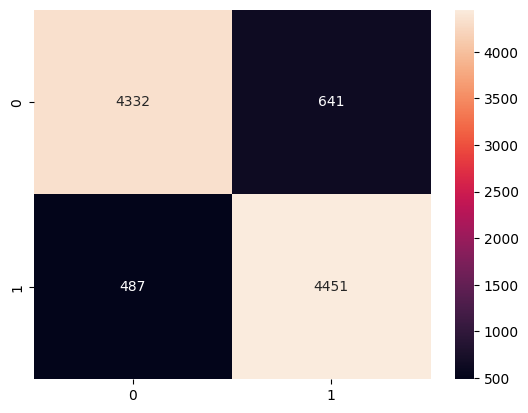

In [82]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d')
plt.show()

In [83]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4973
           1       0.87      0.90      0.89      4938

    accuracy                           0.89      9911
   macro avg       0.89      0.89      0.89      9911
weighted avg       0.89      0.89      0.89      9911

